# Lab 1 - Building Your First Intrusion Detector
### Google Colab runner

This notebook runs the exact same code as the local project - the files in `src/` are identical.

Run the cells in order or run section 4. Or: everything in one command


## 1. Set up the project files

Upload the whole `collab` folder to your Google Drive, then point this cell at it.

In [1]:
# Files already in Google Drive
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/collab'   # <-- EDIT to match where you put the folder

import os
os.chdir(PROJECT)
print('Working directory:', os.getcwd())
print(sorted(os.listdir()))

Mounted at /content/drive
Working directory: /content/drive/MyDrive/collab
['Lab1_IDS_Colab.ipynb', 'README.md', 'data', 'requirements-colab.txt', 'results', 'run_all.py', 'src']


In [2]:
# Environment check
import sys, platform
print('Python :', sys.version.split()[0], '   (local project targets 3.11)')
print('Platform:', platform.platform())
!nproc --all | sed 's/^/CPU cores: /'
!free -g | awk 'NR==2{print "RAM (GB): "$2}'
!df -h /content | awk 'NR==2{print "Disk free: "$4}'

Python : 3.13.15    (local project targets 3.11)
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
CPU cores: 24
RAM (GB): 47
Disk free: 207G


In [3]:
# Install ONLY what the pipeline needs. Fast, and it will not disturb the Colab runtime.
!pip install -q -r requirements-colab.txt

import sklearn, pandas, numpy, matplotlib, joblib, tabulate
print('sklearn    ', sklearn.__version__)
print('pandas     ', pandas.__version__)
print('numpy      ', numpy.__version__)
print('matplotlib ', matplotlib.__version__)
print('joblib     ', joblib.__version__)
print('OK - all imports the pipeline needs are present')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.5 MB/s eta 0:00:00
sklearn     1.6.1
pandas      2.2.3
numpy       2.1.3
matplotlib  3.10.0
joblib      1.5.3
OK - all imports the pipeline needs are present


## 2. Get the dataset

You need any csv file in `data/raw/`. At first we test it with **`Wednesday-workingHours.pcap_ISCX.csv`** (~225 MB) in `data/raw/`.


In [4]:
# The CSV came with the folder in Drive. Nothing to do but check. ---
!ls -lh data/raw/

total 844M
-rw------- 1 root root  74M Sep  6 17:28 Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
-rw------- 1 root root  74M Sep  6 17:28 Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
-rw------- 1 root root  56M Sep  6 17:29 Friday-WorkingHours-Morning.pcap_ISCX.csv
-rw------- 1 root root 169M Sep  6 17:28 Monday-WorkingHours.pcap_ISCX.csv
-rw------- 1 root root  80M Sep  6 17:29 Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
-rw------- 1 root root  50M Sep  6 17:29 Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
-rw------- 1 root root 129M Sep  6 17:28 Tuesday-WorkingHours.pcap_ISCX.csv
-rw------- 1 root root 215M Sep  6 12:02 Wednesday-workingHours.pcap_ISCX.csv


In [5]:
# The filename must match RAW_FILE in src/config.py EXACTLY - capitals, hyphens, dots.
import sys, importlib
sys.path.insert(0, 'src')
import config
importlib.reload(config)   # pick up edits to config.py without a restart

files = getattr(config, 'RAW_FILES', None)
if files is None:
    files = [config.RAW_FILE]
    print('mode: SINGLE file')
else:
    files = list(files)
    print(f'mode: MULTI file - glob matched {len(files)} file(s)')

for f in files:
    print(f"  {'OK     ' if f.exists() else 'MISSING'}  {f.name}")


mode: MULTI file - glob matched 8 file(s)
  OK       Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  OK       Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  OK       Friday-WorkingHours-Morning.pcap_ISCX.csv
  OK       Monday-WorkingHours.pcap_ISCX.csv
  OK       Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  OK       Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  OK       Tuesday-WorkingHours.pcap_ISCX.csv
  OK       Wednesday-workingHours.pcap_ISCX.csv


## 3. Run the pipeline

Run the steps one at a time first. If something breaks you will know exactly which step,
which you would not from `run_all.py`. Section 4 does the whole thing in one command.

In [6]:
!python src/explore.py      # Lab Step 1 - load and look

  loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv ...
  loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv ...
  loading Friday-WorkingHours-Morning.pcap_ISCX.csv ...
  loading Monday-WorkingHours.pcap_ISCX.csv ...
  loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv ...
  loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv ...
  loading Tuesday-WorkingHours.pcap_ISCX.csv ...
  loading Wednesday-workingHours.pcap_ISCX.csv ...
  combined 8 files -> 2,830,743 rows
STEP 1: LOAD AND LOOK

Shape: 2,830,743 rows x 79 columns

First 15 column names:
  - Destination Port
  - Flow Duration
  - Total Fwd Packets
  - Total Backward Packets
  - Total Length of Fwd Packets
  - Total Length of Bwd Packets
  - Fwd Packet Length Max
  - Fwd Packet Length Min
  - Fwd Packet Length Mean
  - Fwd Packet Length Std
  - Bwd Packet Length Max
  - Bwd Packet Length Min
  - Bwd Packet Length Mean
  - Bwd Packet Length Std
  - Flow Bytes/s
  ... and 64 more

How ma

In [7]:
!python src/clean.py        # Lab Step 2 - clean (watch for the PROTECTED line)

  loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv ...
  loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv ...
  loading Friday-WorkingHours-Morning.pcap_ISCX.csv ...
  loading Monday-WorkingHours.pcap_ISCX.csv ...
  loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv ...
  loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv ...
  loading Tuesday-WorkingHours.pcap_ISCX.csv ...
  loading Wednesday-workingHours.pcap_ISCX.csv ...
  combined 8 files -> 2,830,743 rows
STEP 2: CLEAN

Starting with 2,830,743 rows x 79 columns

[1] Dropped 2 ID columns: ['Destination Port', 'Fwd Header Length.1']
[2] Found 4,376 infinity values and 5,734 missing values
    Dropped 2,867 rows containing them
[3] Dropped 594,712 duplicate rows
[4] Dropped 8 constant (zero-variance) columns
[5] No classes below 10 rows
[6] Sampled 20% -> 446,641 rows

Final: 446,641 rows x 69 columns
Saved -> /content/drive/MyDrive/collab/data/processed/clean.csv


In [8]:
!python src/prepare.py      # Lab Steps 3 & 4 - split 60/20/20 and scale

STEPS 3 & 4: SPLIT AND SCALE

Features: 68 columns, 446,641 rows
  train:  267,984 rows (60%)
  val:     89,328 rows (20%)
  test:    89,329 rows (20%)

  attack rate  train=0.1507  val=0.1507  test=0.1507

Scaler fitted on TRAINING data only, then applied to val and test.
Saved -> /content/drive/MyDrive/collab/data/processed/splits.joblib


In [9]:
!python src/train_binary.py # Lab Steps 5 & 6 - LR, Random Forest, MLP.  SLOW: 5-15 min

STEPS 5 & 6: TRAIN BINARY MODELS

--- LogisticRegression ------------------------------------------
  tried {'C': 0.1}  ->  validation macro-F1 = 0.9347
  tried {'C': 1.0}  ->  validation macro-F1 = 0.9420
  tried {'C': 1.0, 'class_weight': 'balanced'}  ->  validation macro-F1 = 0.9021
  WINNER: {'C': 1.0}  (validation macro-F1 0.9420)
  LogisticRegression           acc=0.9721  macroF1=0.9418  recall=0.8325  AUC=0.9915  FAR=0.0032

--- RandomForest ------------------------------------------------
  tried {'n_estimators': 100, 'max_depth': None}  ->  validation macro-F1 = 0.9968
  tried {'n_estimators': 300, 'max_depth': 20}  ->  validation macro-F1 = 0.9969
  WINNER: {'n_estimators': 300, 'max_depth': 20}  (validation macro-F1 0.9969)
  RandomForest                 acc=0.9984  macroF1=0.9968  recall=0.9923  AUC=0.9999  FAR=0.0006

--- MLP (neural network) ----------------------------------------
  tried {'hidden_layer_sizes': (32,)}  ->  validation macro-F1 = 0.9854
  tried {'hidden_la

In [10]:
!python src/ablation.py     # Lab Step 7 - scaling on vs off

STEP 7: ABLATION - with vs. without feature scaling

--- LogisticRegression ------------------------------------------
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
  LogisticRegression [WITHOUT scaling] acc=0.9552  macroF1=0.9075  recall=0.7881  AUC=0.9033  FAR=0.0152
  LogisticRegression [WITH scaling] acc=0.9721  macroF1=0.9418  recall=0.8325  AUC=0.9915  FAR=0.0032

--- RandomForest ------------------------------------------------
  RandomForest [WITHOUT scaling] acc=0.9984  macroF1=0.9968  recall=0.9932  AUC=0.9997  FAR=0.00

In [11]:
!python src/multiclass.py   # which attack type + confusion matrix

MULTICLASS: which kind of attack is it?

Per-attack-type scores on the test set:

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00     75868
                       Bot       0.74      0.65      0.69        57
                      DDoS       1.00      1.00      1.00      5121
             DoS GoldenEye       1.00      0.98      0.99       412
                  DoS Hulk       1.00      0.99      1.00      6914
          DoS Slowhttptest       0.94      0.97      0.95       209
             DoS slowloris       0.98      0.98      0.98       215
               FTP-Patator       1.00      1.00      1.00       237
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.00      0.00      0.00         1
                  PortScan       0.97      0.91      0.94        78
               SSH-Patator       1.00      0.93      0.96       129
  Web Attack - Brute Force       

In [12]:
!python src/compare.py      # Lab Step 8 - the final table

STEP 8: FINAL COMPARISON
| model                                  |   accuracy |   macro_f1 |   recall_attack |   roc_auc |    FAR | notes                                  |
|:---------------------------------------|-----------:|-----------:|----------------:|----------:|-------:|:---------------------------------------|
| LogisticRegression                     |     0.9721 |     0.9418 |          0.8325 |    0.9915 | 0.0032 | {'C': 1.0}                             |
| RandomForest                           |     0.9984 |     0.9968 |          0.9923 |    0.9999 | 0.0006 | {'n_estimators': 300, 'max_depth': 20} |
| MLP (neural network)                   |     0.9948 |     0.9898 |          0.9825 |    0.9995 | 0.003  | {'hidden_layer_sizes': (64, 32)}       |
| LogisticRegression [WITHOUT scaling]   |     0.9552 |     0.9075 |          0.7881 |    0.9033 | 0.0152 | ablation: scaling                      |
| LogisticRegression [WITH scaling]      |     0.9721 |     0.9418 |          0.8

## 4. Or: everything in one command

This is the case where we run start-to-finish and reproduces our numbers.
It re-runs every step above from the raw CSV. Harder or almost impossible to troubleshoot

In [16]:
# Wipe anything from earlier runs first, so no stale numbers survive.
!rm -f data/processed/* results/tables/* results/figures/* results/models/*
!python run_all.py


######################################################################
### Step 1  - explore
######################################################################
  loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv ...
  loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv ...
  loading Friday-WorkingHours-Morning.pcap_ISCX.csv ...
  loading Monday-WorkingHours.pcap_ISCX.csv ...
  loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv ...
  loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv ...
  loading Tuesday-WorkingHours.pcap_ISCX.csv ...
  loading Wednesday-workingHours.pcap_ISCX.csv ...
  combined 8 files -> 2,830,743 rows
STEP 1: LOAD AND LOOK

Shape: 2,830,743 rows x 79 columns

First 15 column names:
  - Destination Port
  - Flow Duration
  - Total Fwd Packets
  - Total Backward Packets
  - Total Length of Fwd Packets
  - Total Length of Bwd Packets
  - Fwd Packet Length Max
  - Fwd Packet Length Min
  - Fwd Packet Length Mean
  - Fwd 

## 5. Look at the results

In [17]:
import pandas as pd
df = pd.read_csv('results/tables/final_comparison.csv')
print(df.to_markdown(index=False))

| model                                  |   accuracy |   macro_f1 |   recall_attack |   roc_auc |    FAR | notes                                  |
|:---------------------------------------|-----------:|-----------:|----------------:|----------:|-------:|:---------------------------------------|
| LogisticRegression                     |     0.9721 |     0.9418 |          0.8325 |    0.9915 | 0.0032 | {'C': 1.0}                             |
| RandomForest                           |     0.9984 |     0.9968 |          0.9923 |    0.9999 | 0.0006 | {'n_estimators': 300, 'max_depth': 20} |
| MLP (neural network)                   |     0.9948 |     0.9898 |          0.9825 |    0.9995 | 0.003  | {'hidden_layer_sizes': (64, 32)}       |
| LogisticRegression [WITHOUT scaling]   |     0.9552 |     0.9075 |          0.7881 |    0.9033 | 0.0152 | ablation: scaling                      |
| LogisticRegression [WITH scaling]      |     0.9721 |     0.9418 |          0.8325 |    0.9915 | 0.0032 


class_balance.png


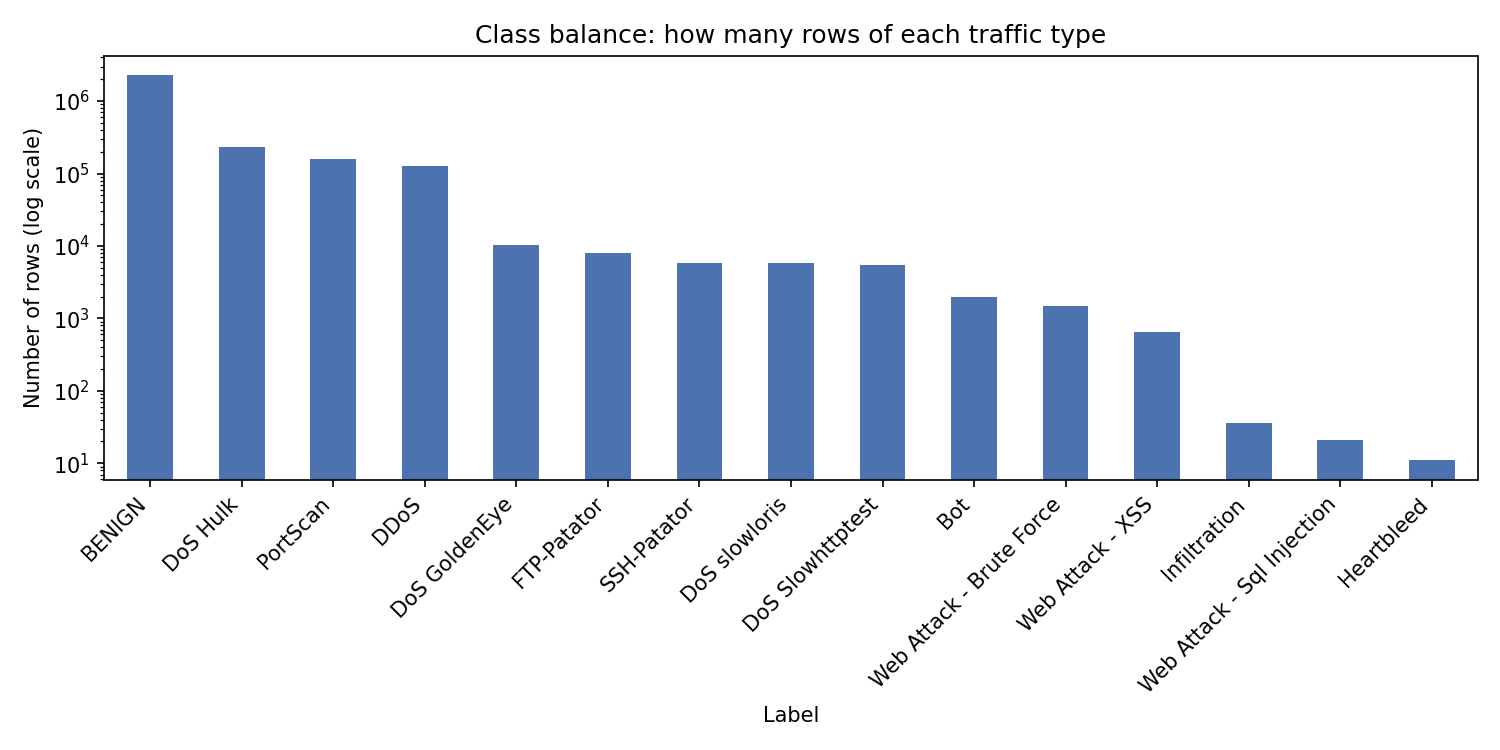


confusion_LogisticRegression.png


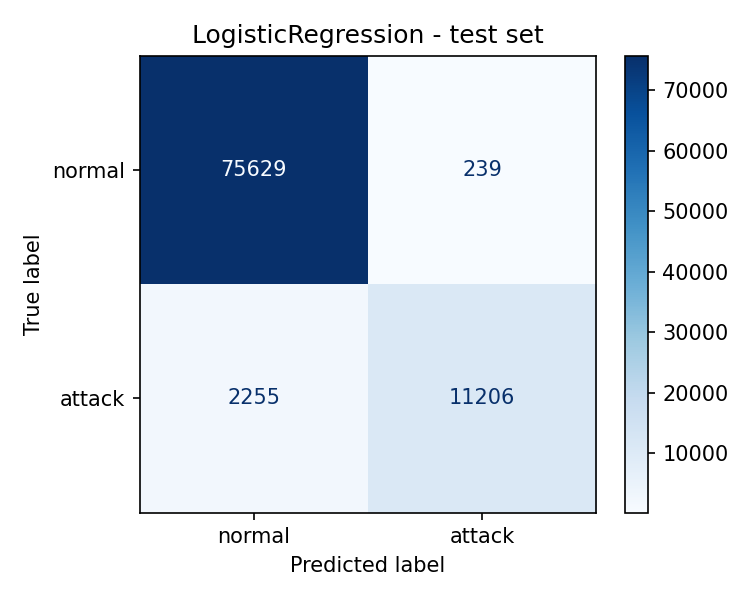


confusion_MLP.png


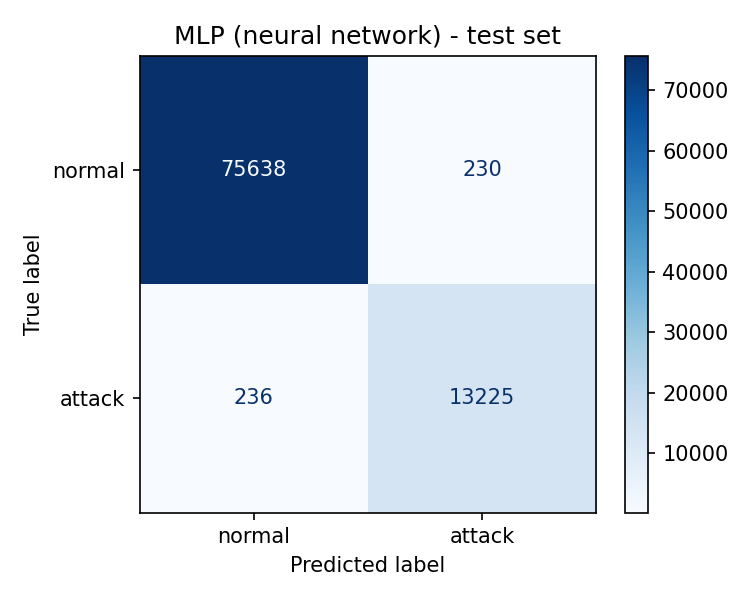


confusion_RandomForest.png


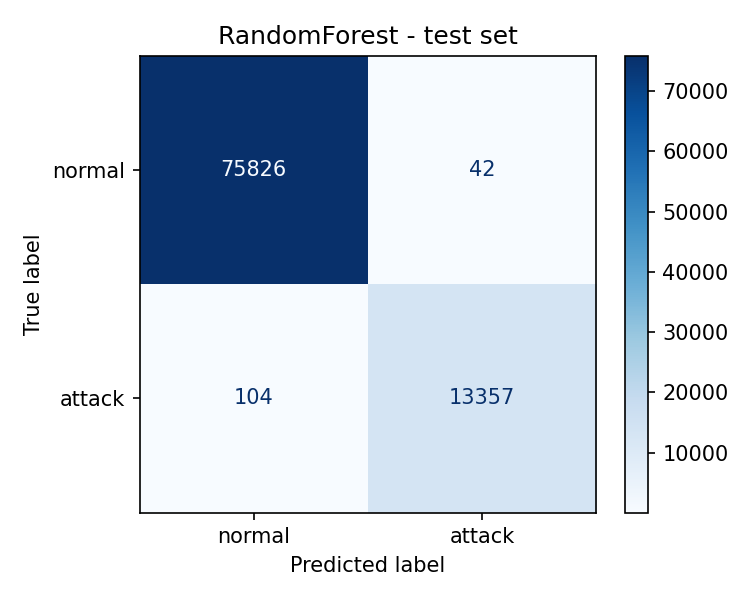


confusion_multiclass.png


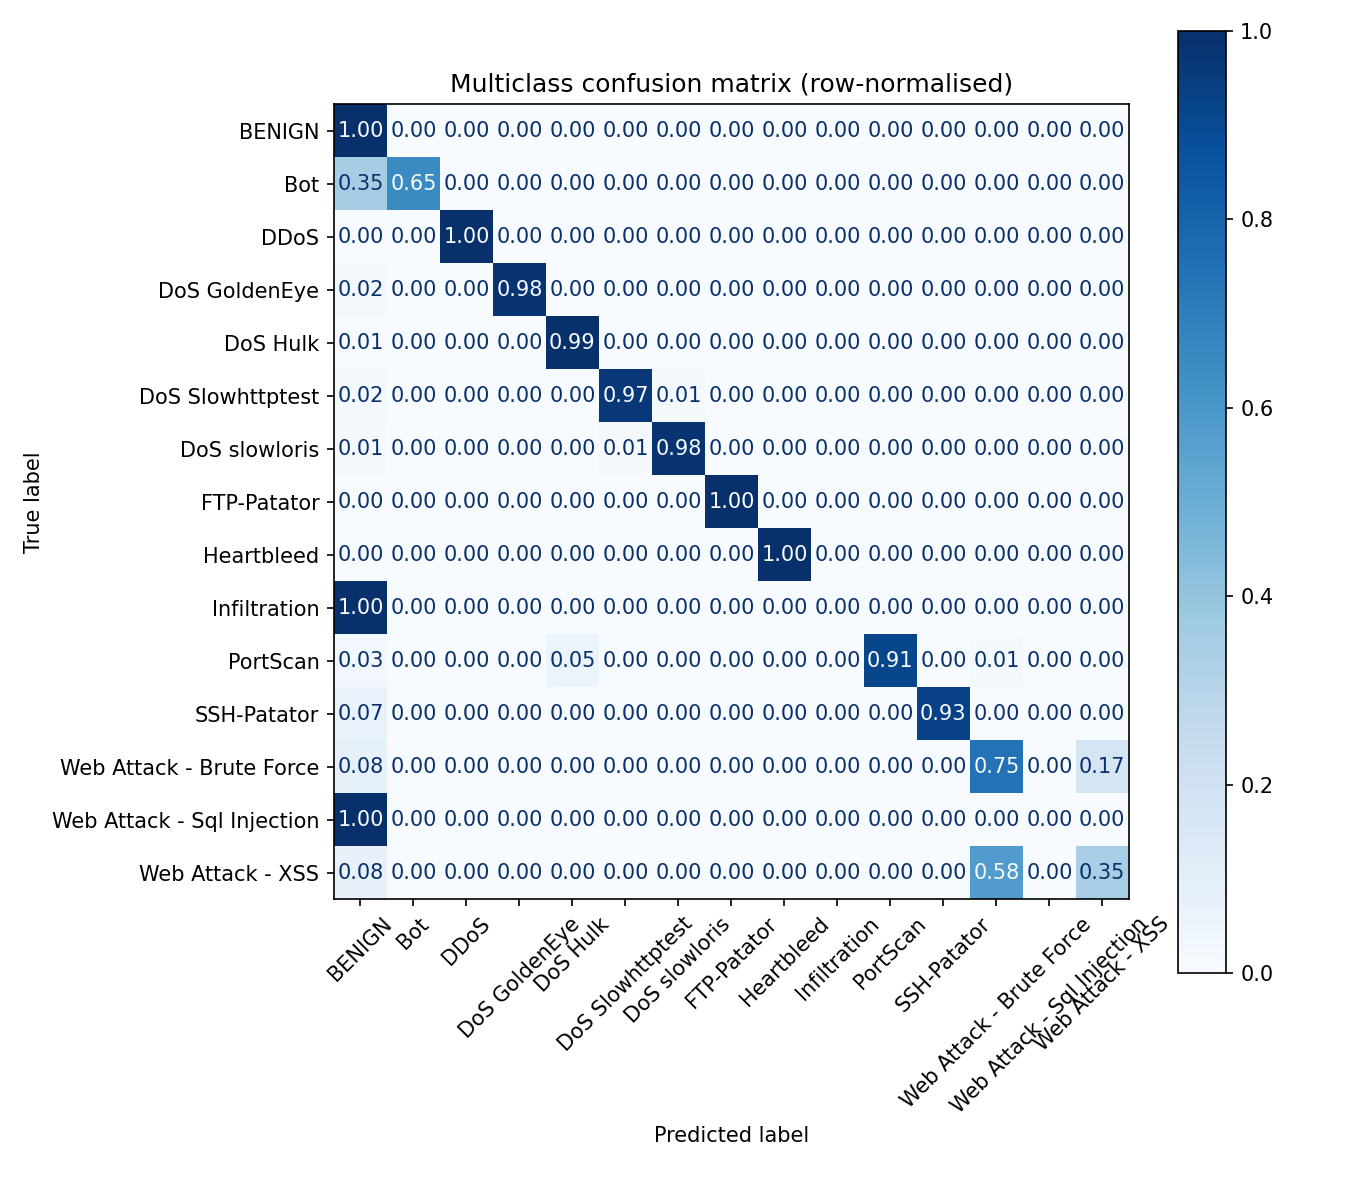


model_comparison.png


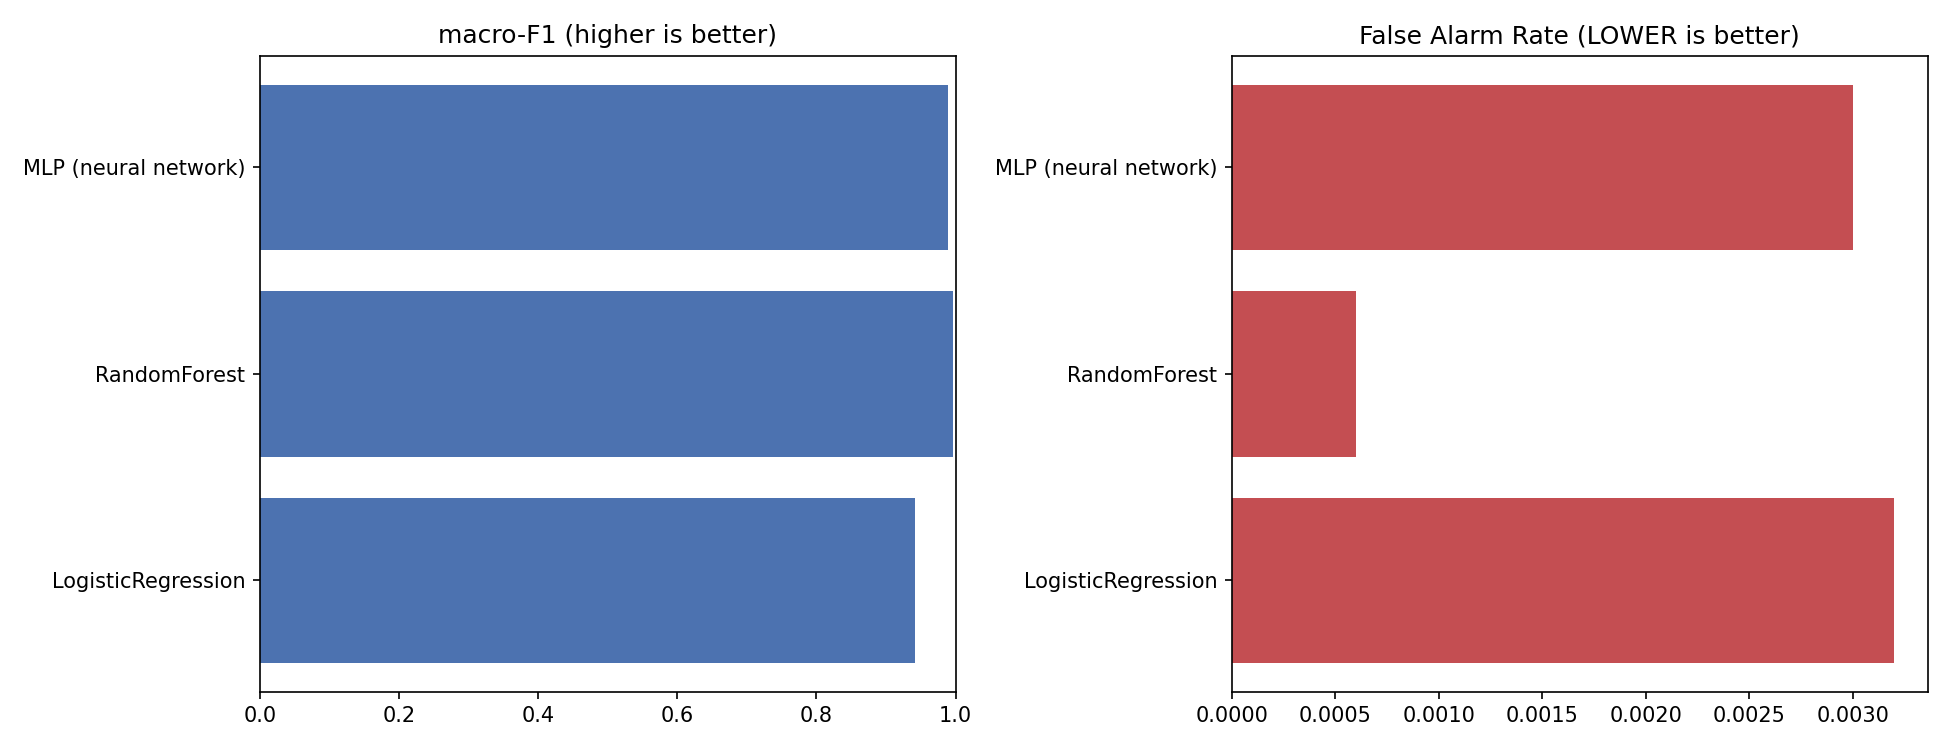

In [18]:
from IPython.display import Image, display
import pathlib
for p in sorted(pathlib.Path('results/figures').glob('*.png')):
    print('\n' + '=' * 70); print(p.name); print('=' * 70)
    display(Image(filename=str(p)))

## 6. Save your results

Colab wipes local disk on disconnect. Do one of these before you close the tab.

In [19]:
# Zip everything and download it
!zip -qr results-all.zip results/
from google.colab import files
files.download('results-all.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Testing without the real dataset

If the download is slow, this generates a small **fake** `splits.joblib` so you can check the
modelling half runs. It takes seconds.

**Every number it produces is meaningless.** Delete `data/processed/` and run the real pipeline

In [ ]:
!python src/make_dummy_splits.py
!python src/train_binary.py
!python src/compare.py

In [ ]:
# CRITICAL: destroy the fake data and everything computed from it.
!rm -f data/processed/* results/tables/* results/figures/* results/models/*
!echo "wiped - files remaining: $(find data/processed results -type f | wc -l)"